# Ultra L1C L2 validation (Oct 2025)

Setup

In [1]:
import cdflib
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import math
import scipy.stats as stats

nside=32


rootdir = '/Users/demajr1/files/imap_ultra/validation/2025Oct/'
l1cFname = rootdir+'imap_ultra_l1c_90sensor-spacecraftpset-nonproton_20260926_v001.cdf'
l2Fname = rootdir+'imap_ultra_l2_u90-ena-h-hf-nsp-full-hae-2deg-0mo_20260926_v002.cdf'

l1c = cdflib.CDF(l1cFname)
l2= cdflib.CDF(l2Fname)

l1cEn = l1c['energy_bin_geometric_mean']
l2En = l2['energy_label'].astype(float)[:,0]



## CDF names and dimensions, basic checks
L1C:

In [2]:
l1cNames = l1c.cdf_info().zVariables
for name in l1cNames:
    print(f'{name}: {np.shape(l1c[name])}')

counts: (1, 24, 12288)
latitude: (1, 12288)
longitude: (1, 12288)
background_rates: (1, 24, 12288)
exposure_factor: (1, 24, 12288)
energy_bin_delta: (1, 24)
quality_flags: (1, 12288)
sensitivity: (1, 24, 12288)
efficiency: (1, 24, 12288)
geometric_function: (24, 12288)
dead_time_ratio: (15000,)
scatter_theta: (24, 12288)
scatter_phi: (24, 12288)
scatter_threshold: (24,)
energy_delta_minus: (24,)
energy_delta_plus: (24,)
epoch: (1,)
pixel_index: (12288,)
energy_bin_geometric_mean: (24,)
spin_phase_step: (15000,)


L2:

In [3]:

l2Names = l2.cdf_info().zVariables
for name in l2Names:
    print(f'{name}: {np.shape(l2[name])}')


counts: (1, 24, 180, 90)
obs_date_range: (1, 24, 180, 90)
sensitivity: (1, 24, 180, 90)
background_rates: (1, 24, 180, 90)
obs_date: (1, 24, 180, 90)
efficiency: (1, 24, 180, 90)
exposure_factor: (1, 24, 180, 90)
geometric_function: (24, 180, 90)
positional_uncert_theta: (24, 180, 90)
positional_uncert_phi: (24, 180, 90)
ena_intensity: (1, 24, 180, 90)
ena_intensity_stat_unc: (1, 24, 180, 90)
solid_angle: (1, 180, 90)
longitude_delta: (1,)
latitude_delta: (1,)
ena_intensity_sys_err: (1, 24, 180, 90)
epoch: (1,)
energy: (24,)
longitude: (180,)
latitude: (90,)
energy_label: (24, 1)
longitude_label: (180, 1)
latitude_label: (90, 1)
epoch_delta: (1,)
energy_delta_minus: (24,)
energy_delta_plus: (24,)


Check for consistent energies

In [4]:
for ic in range(len(l1cEn)):
    print(f"{ic}  l1: {l1cEn[ic]} \tl2: {l2En[ic]} \tdiff: {l1cEn[ic] - l2En[ic]}")

0  l1: 3.7422583051176748 	l2: 3.7422583051176748 	diff: 0.0
1  l1: 4.573871261810494 	l2: 4.573871261810494 	diff: 0.0
2  l1: 5.590287097768385 	l2: 5.590287097768385 	diff: 0.0
3  l1: 6.832573119494692 	l2: 6.832573119494692 	diff: 0.0
4  l1: 8.35092270160462 	l2: 8.35092270160462 	diff: 0.0
5  l1: 10.206683301961181 	l2: 10.206683301961181 	diff: 0.0
6  l1: 12.474835146841436 	l2: 12.474835146841436 	diff: 0.0
7  l1: 15.24702073502845 	l2: 15.24702073502845 	diff: 0.0
8  l1: 18.635247565034774 	l2: 18.635247565034774 	diff: 0.0
9  l1: 22.776413690598076 	l2: 22.776413690598076 	diff: 0.0
10  l1: 27.83783895517543 	l2: 27.83783895517543 	diff: 0.0
11  l1: 34.02402538965885 	l2: 34.02402538965885 	diff: 0.0
12  l1: 41.58491992069417 	l2: 41.58491992069417 	diff: 0.0
13  l1: 50.82601323640397 	l2: 50.82601323640397 	diff: 0.0
14  l1: 62.120682844493786 	l2: 62.120682844493786 	diff: 0.0
15  l1: 75.92527903215911 	l2: 75.92527903215911 	diff: 0.0
16  l1: 92.79756326152787 	l2: 92.797563

Note - this is probably NOT how we want to do this - i.e., L2 energy bins will be broader - possibly just rebinned L1C.

## Quick L2 check
Plots of intensity for all 24 energy channels

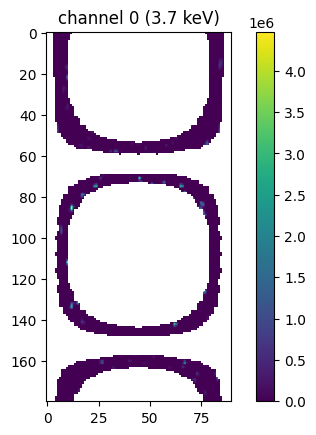

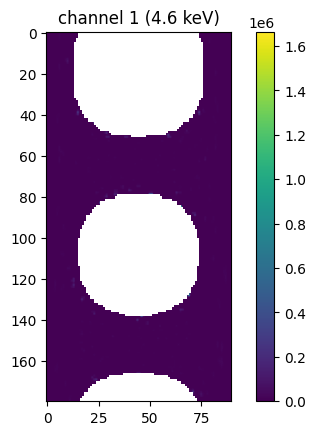

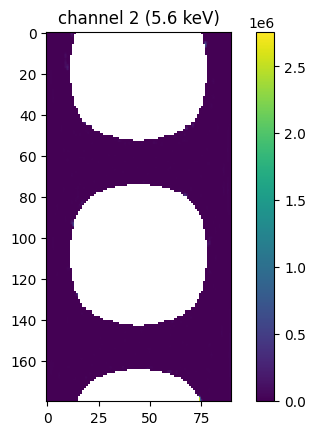

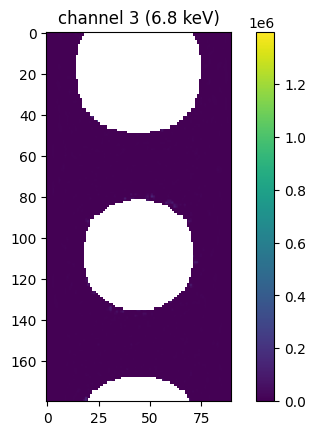

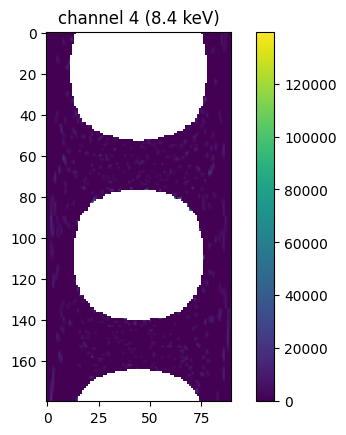

/var/folders/m6/1ls9h6ps0kn7jgklb437svmc0000gn/T/ipykernel_67252/3320928330.py:5: RuntimeWarning: Mean of empty slice
  mean_intensity[ic] = np.nanmean(intensity)


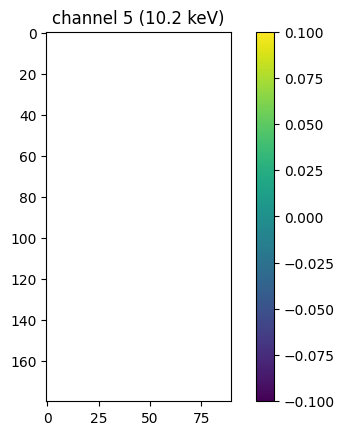

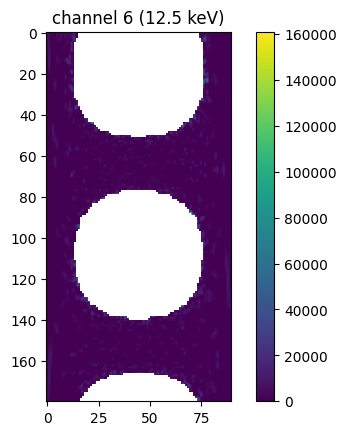

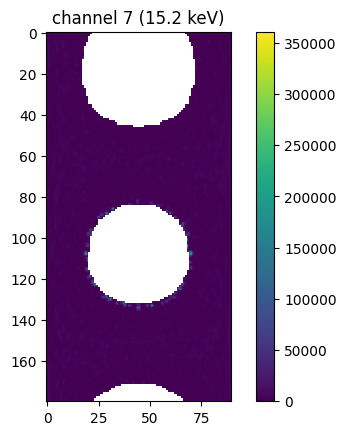

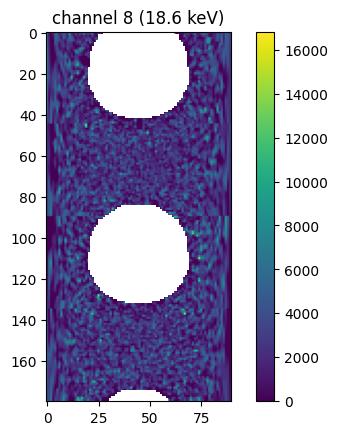

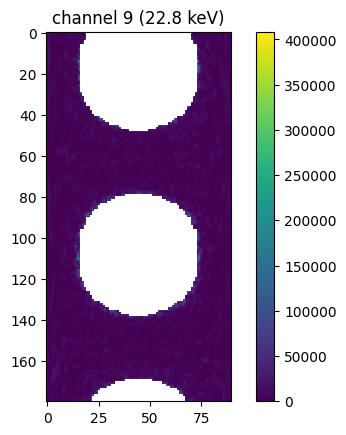

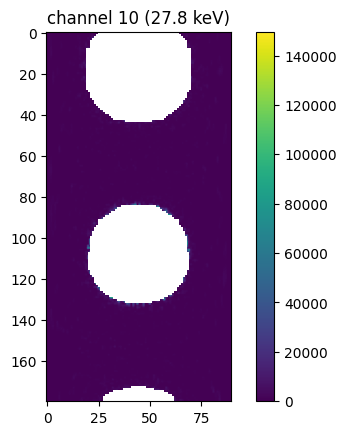

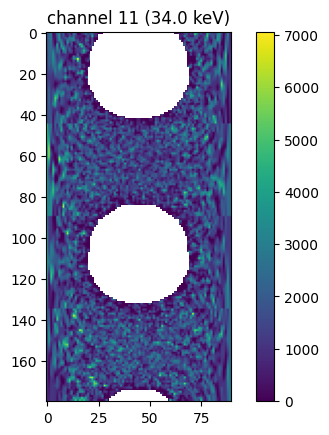

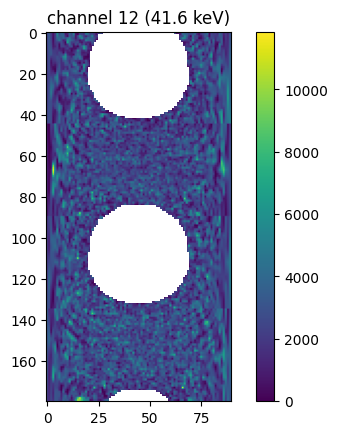

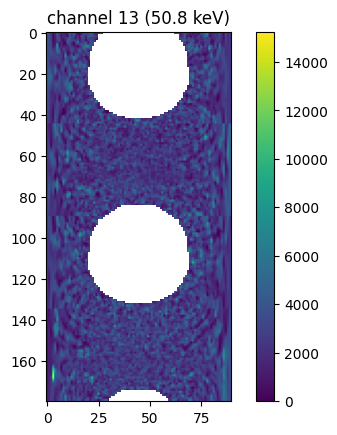

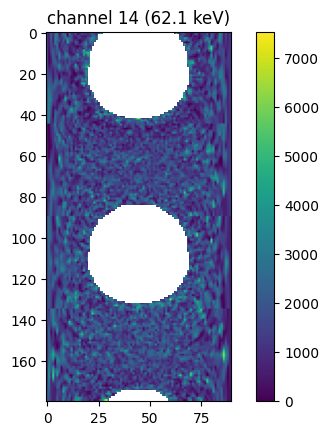

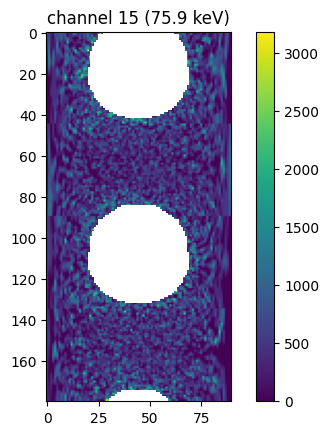

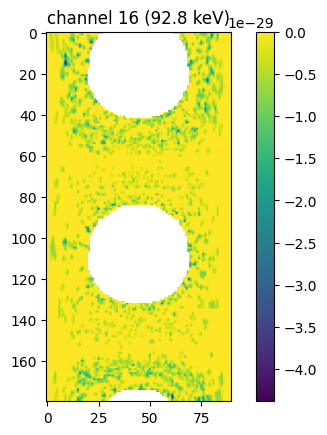

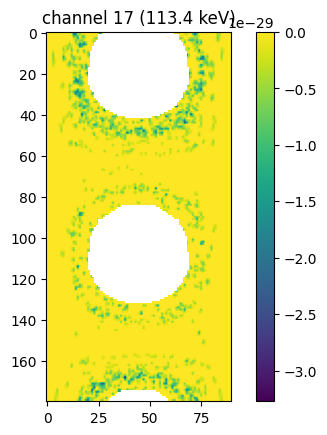

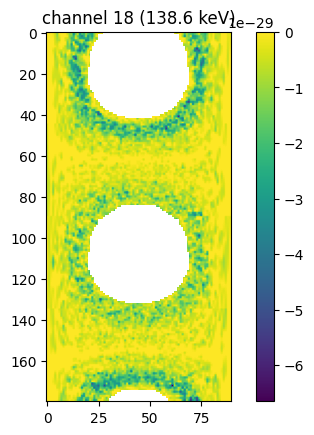

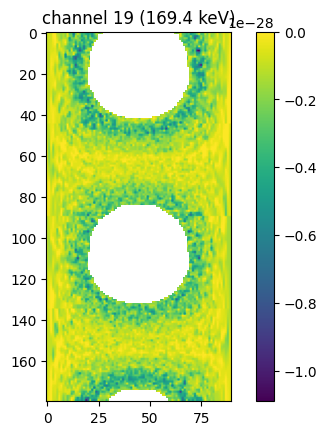

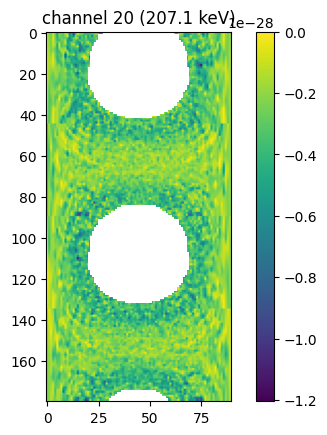

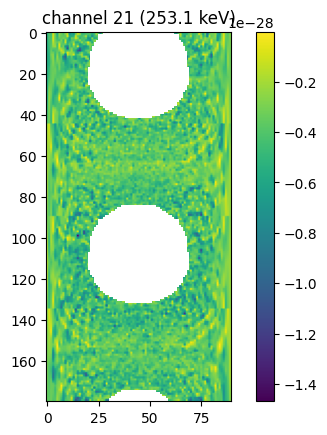

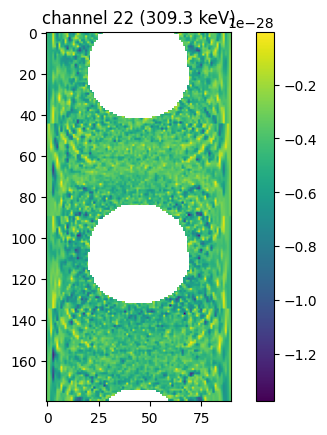

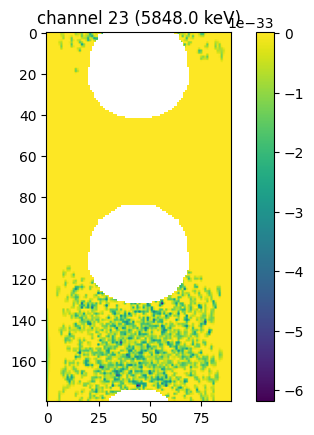

In [5]:
mean_intensity = np.empty_like(l2En)
for ic in range(len(l2En)):
    intensity = l2['ena_intensity'][0,ic,:,:]
    intensity = np.where(intensity > -1.e30,intensity,math.nan)
    mean_intensity[ic] = np.nanmean(intensity)
    plt.imshow(intensity)
    plt.title(f'channel {ic} ({l2En[ic]:.1f} keV)')
    plt.colorbar()
    plt.show()

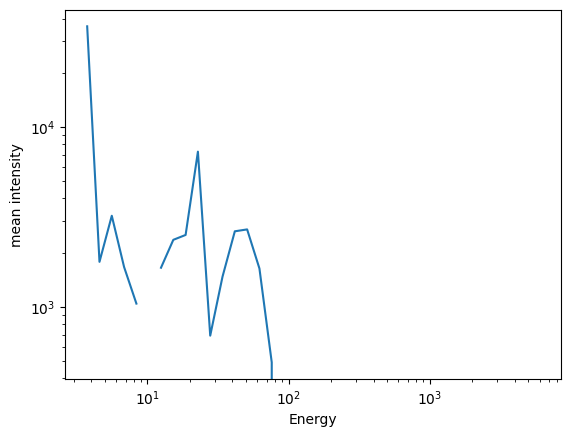

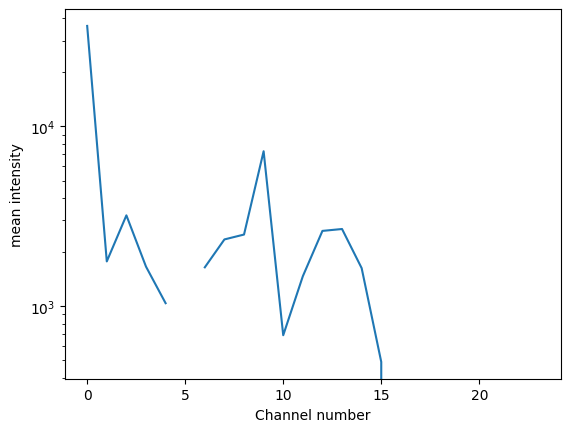

In [6]:
plt.plot(l2En, mean_intensity)
plt.xlabel('Energy')
plt.ylabel('mean intensity')
plt.yscale('log')
plt.xscale('log')
plt.show()

plt.plot(mean_intensity)
plt.xlabel('Channel number')
plt.ylabel('mean intensity')
plt.yscale('log')
plt.show()


The following are the immediate issues with these level 2 
- Given the initial dataset, the mean intensity in each channel should equal 2, but the average values are both too high and a function of energy
- Channel 5 (~10 keV) does not exist for some reason

## Level 1C analysis

If we have a channel with significant counts, we can calculate a Level 1C intensity to compare to level 2, so we calculate exposure weighted mean counts for each channel. Before doing so, we note that the *exposure factor* for channel 5 is filled with zero:

In [7]:
np.sum(l1c['exposure_factor'][0,5,:])

np.float64(0.0)

This is the reason that the level 2 data here is missing as well. 

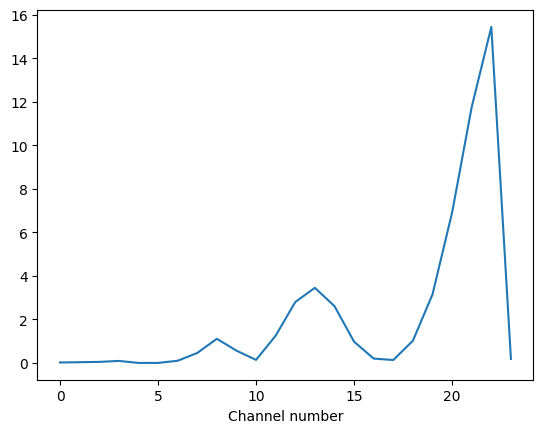

In [8]:
mean_counts = np.zeros_like(l1cEn)
mean_counts[0:4] = np.average(l1c['counts'][0,0:4,:],weights=l1c['exposure_factor'][0,0:4,:],axis=1)
mean_counts[6:] = np.average(l1c['counts'][0,6:,:],weights=l1c['exposure_factor'][0,6:,:],axis=1)
plt.plot(mean_counts)
plt.ylabel = 'weighted mean counts'
plt.xlabel('Channel number')
plt.show()

We concentrate on channels 13 (50 keV) and 20 (keV). Channel 13 has about 4 counts/pixel, which small but should be enough to calculate a flux. Channnel 20 has enough counts/pixel for flux calculation, but the level 2 numbers for it are much too small.

The exposure factors for these two channels are as follows

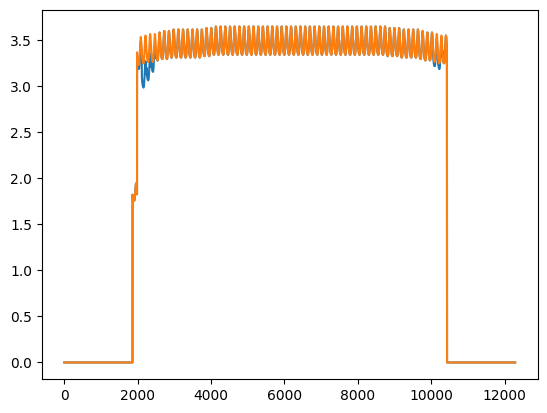

In [9]:
plt.plot(np.ndarray.flatten(l1c['exposure_factor'][0,13,:]))
plt.plot(np.ndarray.flatten(l1c['exposure_factor'][0,20,:]))
plt.show()

Creating a mask where the exposure time is significant

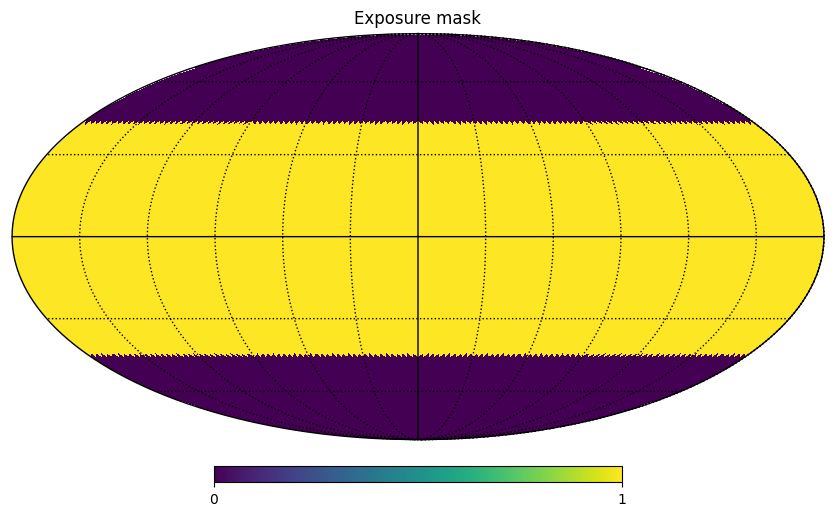

In [10]:
ii=np.nonzero(l1c['exposure_factor'][0,20,:]>3)[0]
expmask = np.zeros_like(l1c['exposure_factor'][0,20,:])
expmask[ii] = 1
hp.mollview(expmask,title='Exposure mask')
hp.graticule()
plt.show()

Looking at the histograms of each channel:

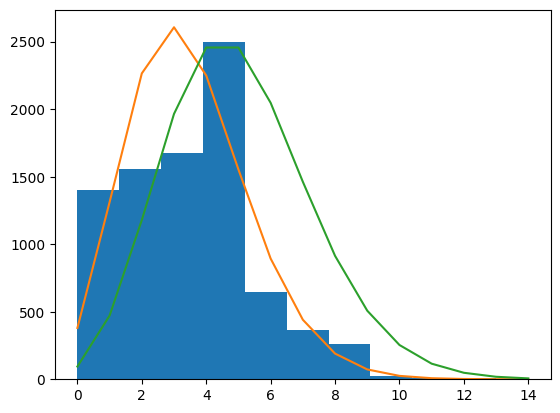

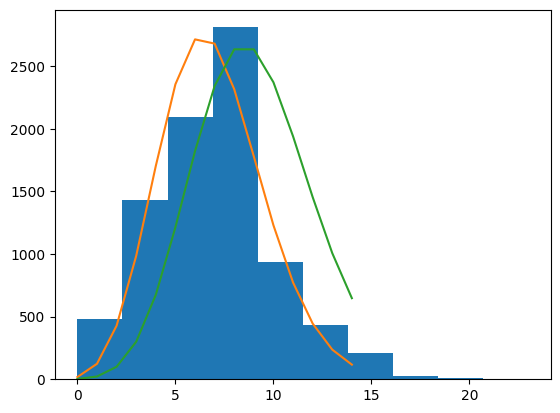

In [11]:
plt.hist(l1c['counts'][0,13,ii])
plt.plot(np.arange(15),stats.poisson.pmf(np.arange(15),mean_counts[13])*12000)
plt.plot(np.arange(15),stats.poisson.pmf(np.arange(15),5)*14000)
plt.show()
plt.hist(l1c['counts'][0,20,ii])
plt.plot(np.arange(15),stats.poisson.pmf(np.arange(15),mean_counts[20])*18000)
plt.plot(np.arange(15),stats.poisson.pmf(np.arange(15),9)*20000)
plt.show()

Clearly, these values of counts do not follow a poisson distribution.

Calculating various quantities for the flux calculation - channel 13

In [12]:
ic=13
cnts = l1c['counts'][0,ic,ii]
tex =  l1c['exposure_factor'][0,ic,ii]
bkg =  l1c['background_rates'][0,ic,ii]
bigs = l1c['sensitivity'][0,ic,ii]
rate = cnts/tex
crate = rate - bkg
omega = np.pi*4/hp.nside2npix(nside)
den = l1c['energy_delta_plus'][ic]+l1c['energy_delta_minus'][ic]
intensity = crate/(bigs*omega*den)

print(f"l1c mean :{np.mean(intensity)} l2 mean: {mean_intensity[ic]}")

l1c mean :2667.0198220794405 l2 mean: 2688.3269259353824


For channel 20:

In [13]:
ic=20
cnts = l1c['counts'][0,ic,ii]
tex =  l1c['exposure_factor'][0,ic,ii]
bkg =  l1c['background_rates'][0,ic,ii]
bigs = l1c['sensitivity'][0,ic,ii]
rate = cnts/tex
crate = rate - bkg
omega = np.pi*4/hp.nside2npix(nside)
den = l1c['energy_delta_plus'][ic]+l1c['energy_delta_minus'][ic]
intensity = crate/(bigs*omega*den)

print(f"l1c mean :{np.mean(intensity)} l2 mean: {mean_intensity[ic]}")

l1c mean :-3.046016467029511e-29 l2 mean: -2.837680054792076e-29


So it looks like the the level 2 code may be working as expected, but the l1C calculations are not done correctly. look at what goes in to a representative pixel

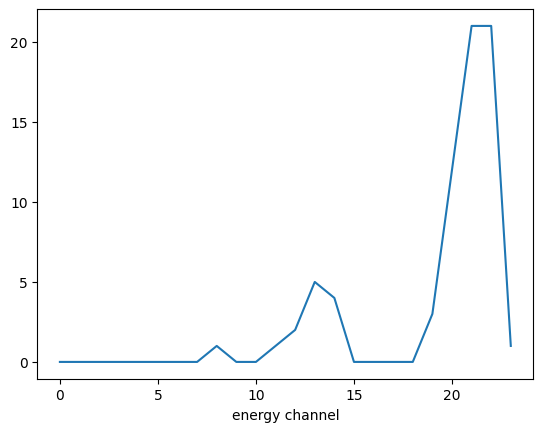

In [14]:
plt.plot(l1c['counts'][0,:,6001])
plt.xlabel("energy channel")
plt.show()


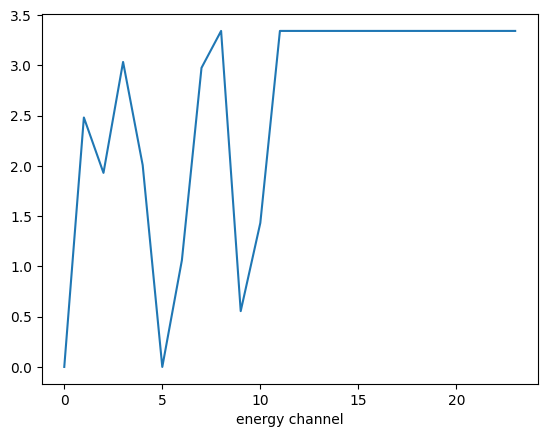

In [15]:
plt.plot(l1c['exposure_factor'][0,:,6001])
plt.xlabel("energy channel")
plt.show()

/var/folders/m6/1ls9h6ps0kn7jgklb437svmc0000gn/T/ipykernel_67252/4077726041.py:1: RuntimeWarning: invalid value encountered in divide
  plt.plot(l1c['counts'][0,:,6001]/l1c['exposure_factor'][0,:,6001])


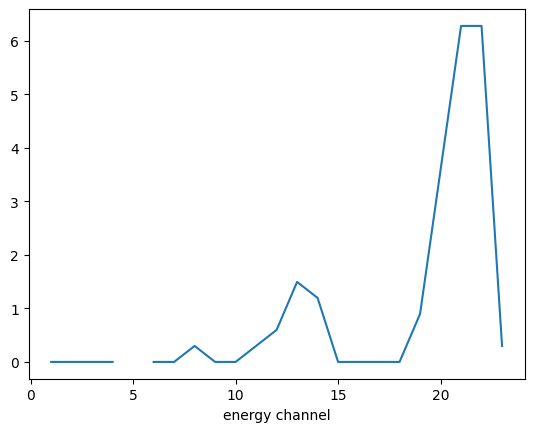

In [16]:
plt.plot(l1c['counts'][0,:,6001]/l1c['exposure_factor'][0,:,6001])
plt.xlabel("energy channel")
plt.show()

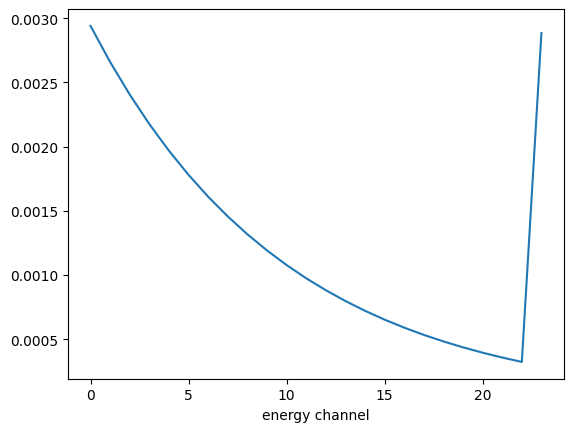

In [17]:
plt.plot(l1c['background_rates'][0,:,6001])
plt.xlabel("energy channel")
plt.show()

/var/folders/m6/1ls9h6ps0kn7jgklb437svmc0000gn/T/ipykernel_67252/3154054046.py:1: RuntimeWarning: invalid value encountered in divide
  plt.plot(l1c['counts'][0,:,6001]/l1c['exposure_factor'][0,:,6001] - l1c['background_rates'][0,:,6001])


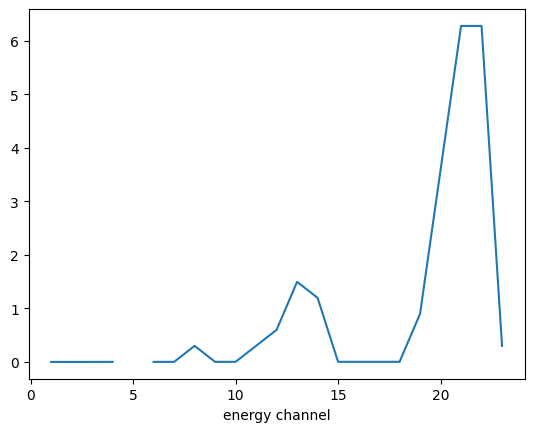

In [18]:
plt.plot(l1c['counts'][0,:,6001]/l1c['exposure_factor'][0,:,6001] - l1c['background_rates'][0,:,6001])
plt.xlabel("energy channel")
plt.show()

/var/folders/m6/1ls9h6ps0kn7jgklb437svmc0000gn/T/ipykernel_67252/1060584061.py:1: RuntimeWarning: invalid value encountered in divide
  crate = l1c['counts'][0,:,6001]/l1c['exposure_factor'][0,:,6001] - l1c['background_rates'][0,:,6001]


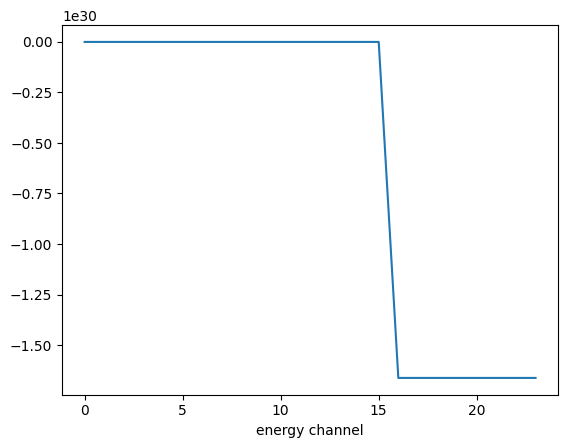

In [19]:
crate = l1c['counts'][0,:,6001]/l1c['exposure_factor'][0,:,6001] - l1c['background_rates'][0,:,6001]
plt.plot(l1c['sensitivity'][0,:,6001])
plt.xlabel("energy channel")
plt.show()

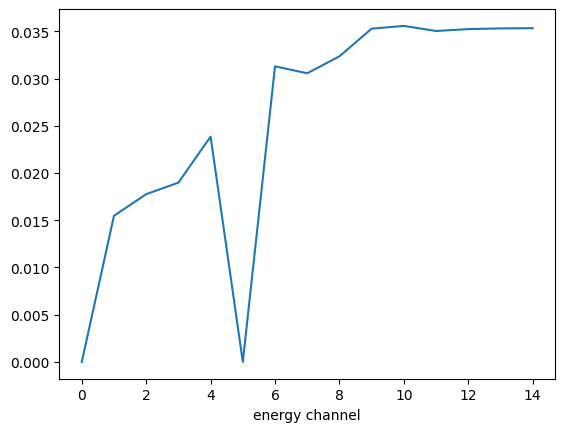

In [20]:
plt.plot(l1c['sensitivity'][0,0:15,6001])
plt.xlabel("energy channel")
plt.show()

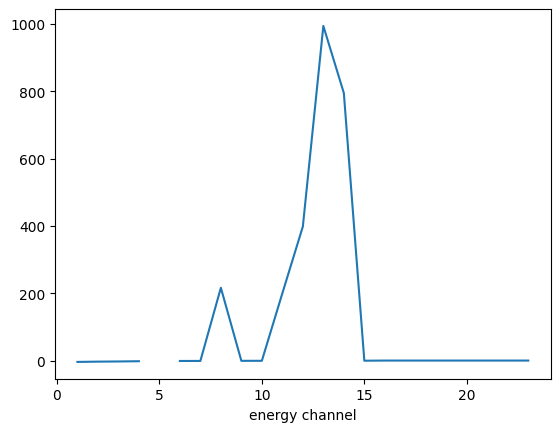

In [22]:
plt.plot(crate/(l1c['sensitivity'][0,:,6001]*omega*den))
plt.xlabel("energy channel")
plt.show()